In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Membaca Dataset Mentah CO (365 Hari)
raw_path = '../data/csv/timeseries/CO_gresik_timeseries.csv'
df_raw = pd.read_csv(raw_path)
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw = df_raw.sort_values('date').reset_index(drop=True)

# Hitung statistik celah data awal
total_rows = len(df_raw)
nan_awal = df_raw['CO'].isna().sum()
valid_awal = df_raw['CO'].notna().sum()

print(f"Total Baris Observasi   : {total_rows} hari")
print(f"Jumlah Data Valid Awal  : {valid_awal} hari ({valid_awal/total_rows*100:.2f}%)")
print(f"Jumlah Missing (NaN)    : {nan_awal} hari ({nan_awal/total_rows*100:.2f}%)")

Total Baris Observasi   : 365 hari
Jumlah Data Valid Awal  : 192 hari (52.60%)
Jumlah Missing (NaN)    : 173 hari (47.40%)


In [2]:
# 2. Deteksi Outlier dengan Metode IQR pada Data Valid
q1 = df_raw['CO'].quantile(0.25)
q3 = df_raw['CO'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Masking Outlier
is_outlier = (df_raw['CO'] < lower_bound) | (df_raw['CO'] > upper_bound)
jumlah_outlier = is_outlier.sum()

print(f"Kuartil 1 (Q1)           : {q1:.6f} mol/m²")
print(f"Kuartil 3 (Q3)           : {q3:.6f} mol/m²")
print(f"IQR (Q3 - Q1)            : {iqr:.6f} mol/m²")
print(f"Batas Bawah (Lower Bound): {lower_bound:.6f} mol/m²")
print(f"Batas Atas (Upper Bound) : {upper_bound:.6f} mol/m²")
print(f"Jumlah Outlier Terdeteksi: {jumlah_outlier} hari")

# Tabel Detail Tanggal & Nilai Outlier Terdeteksi
df_outliers = df_raw[is_outlier][['date', 'CO']].copy()
df_outliers['date'] = df_outliers['date'].dt.strftime('%Y-%m-%d')
print("\nDaftar Tanggal & Nilai Outlier Terdeteksi secara Akurat:")
print(df_outliers.to_string(index=False))

Kuartil 1 (Q1)           : 0.026530 mol/m²
Kuartil 3 (Q3)           : 0.030774 mol/m²
IQR (Q3 - Q1)            : 0.004244 mol/m²
Batas Bawah (Lower Bound): 0.020164 mol/m²
Batas Atas (Upper Bound) : 0.037140 mol/m²
Jumlah Outlier Terdeteksi: 11 hari

Daftar Tanggal & Nilai Outlier Terdeteksi secara Akurat:
      date       CO
2025-09-14 0.017361
2025-09-24 0.041642
2025-10-08 0.039112
2025-10-09 0.045237
2026-04-05 0.017621
2026-05-05 0.017592
2026-05-12 0.016968
2026-06-13 0.018679
2026-07-15 0.019071
2026-08-10 0.038350
2026-08-14 0.039100


In [3]:
from pyod.models.iforest import IForest
from pyod.models.knn import KNN
from pyod.models.lof import LOF
from pyod.models.copod import COPOD
from pyod.models.ecod import ECOD

# 1. Persiapan Data Valid CO untuk 5 Metode Outlier
df_valid = df_raw.dropna(subset=['CO']).copy()
X = df_valid[['CO']].values

contamination_rate = 0.05
models = {
    'Isolation Forest': IForest(contamination=contamination_rate, random_state=42),
    'KNN': KNN(contamination=contamination_rate),
    'LOF': LOF(contamination=contamination_rate),
    'COPOD': COPOD(contamination=contamination_rate),
    'ECOD': ECOD(contamination=contamination_rate)
}

HARI_MAP = {'Monday': 'Senin', 'Tuesday': 'Selasa', 'Wednesday': 'Rabu', 'Thursday': 'Kamis', 'Friday': 'Jumat', 'Saturday': 'Sabtu', 'Sunday': 'Minggu'}
BULAN_MAP = {1: 'Januari', 2: 'Februari', 3: 'Maret', 4: 'April', 5: 'Mei', 6: 'Juni', 7: 'Juli', 8: 'Agustus', 9: 'September', 10: 'Oktober', 11: 'November', 12: 'Desember'}

print("==========================================================================")
print("             PERBANDINGAN 5 METODE OUTLIER MACHINE LEARNING (CO)")
print("==========================================================================")
print(f"Total Data Valid CO: {len(df_valid)} hari\n")

for name, model in models.items():
    model.fit(X)
    df_valid[f'outlier_{name}'] = model.labels_
    outliers_m = df_valid[df_valid[f'outlier_{name}'] == 1]
    print(f">>> Metode: {name} | Jumlah Outlier Terdeteksi: {len(outliers_m)} hari")
    for idx, row in outliers_m.iterrows():
        dt = row['date']
        hari = HARI_MAP[dt.strftime('%A')]
        print(f"    • {hari}, {dt.day} {BULAN_MAP[dt.month]} {dt.year} | Nilai CO: {row['CO']:.4f}")
    print()

             PERBANDINGAN 5 METODE OUTLIER MACHINE LEARNING (CO)
Total Data Valid CO: 192 hari



>>> Metode: Isolation Forest | Jumlah Outlier Terdeteksi: 10 hari
    • Minggu, 14 September 2025 | Nilai CO: 0.0174
    • Rabu, 24 September 2025 | Nilai CO: 0.0416
    • Kamis, 9 Oktober 2025 | Nilai CO: 0.0452
    • Minggu, 5 April 2026 | Nilai CO: 0.0176
    • Selasa, 5 Mei 2026 | Nilai CO: 0.0176
    • Selasa, 12 Mei 2026 | Nilai CO: 0.0170
    • Sabtu, 13 Juni 2026 | Nilai CO: 0.0187
    • Senin, 29 Juni 2026 | Nilai CO: 0.0214
    • Rabu, 15 Juli 2026 | Nilai CO: 0.0191
    • Senin, 10 Agustus 2026 | Nilai CO: 0.0384

>>> Metode: KNN | Jumlah Outlier Terdeteksi: 10 hari
    • Minggu, 14 September 2025 | Nilai CO: 0.0174
    • Rabu, 24 September 2025 | Nilai CO: 0.0416
    • Rabu, 8 Oktober 2025 | Nilai CO: 0.0391
    • Kamis, 9 Oktober 2025 | Nilai CO: 0.0452
    • Selasa, 12 Mei 2026 | Nilai CO: 0.0170
    • Sabtu, 13 Juni 2026 | Nilai CO: 0.0187
    • Senin, 29 Juni 2026 | Nilai CO: 0.0214
    • Rabu, 15 Juli 2026 | Nilai CO: 0.0191
    • Senin, 10 Agustus 2026 | Nilai CO: 0.0

>>> Metode: COPOD | Jumlah Outlier Terdeteksi: 10 hari
    • Rabu, 24 September 2025 | Nilai CO: 0.0416
    • Jumat, 3 Oktober 2025 | Nilai CO: 0.0351
    • Rabu, 8 Oktober 2025 | Nilai CO: 0.0391
    • Kamis, 9 Oktober 2025 | Nilai CO: 0.0452
    • Jumat, 10 Oktober 2025 | Nilai CO: 0.0361
    • Minggu, 1 Februari 2026 | Nilai CO: 0.0359
    • Senin, 9 Maret 2026 | Nilai CO: 0.0355
    • Rabu, 22 Juli 2026 | Nilai CO: 0.0367
    • Senin, 10 Agustus 2026 | Nilai CO: 0.0384
    • Jumat, 14 Agustus 2026 | Nilai CO: 0.0391

>>> Metode: ECOD | Jumlah Outlier Terdeteksi: 10 hari
    • Minggu, 14 September 2025 | Nilai CO: 0.0174
    • Rabu, 24 September 2025 | Nilai CO: 0.0416
    • Rabu, 8 Oktober 2025 | Nilai CO: 0.0391
    • Kamis, 9 Oktober 2025 | Nilai CO: 0.0452
    • Minggu, 5 April 2026 | Nilai CO: 0.0176
    • Selasa, 5 Mei 2026 | Nilai CO: 0.0176
    • Selasa, 12 Mei 2026 | Nilai CO: 0.0170
    • Sabtu, 13 Juni 2026 | Nilai CO: 0.0187
    • Senin, 10 Agustus 2026 | Nilai CO: 0.038

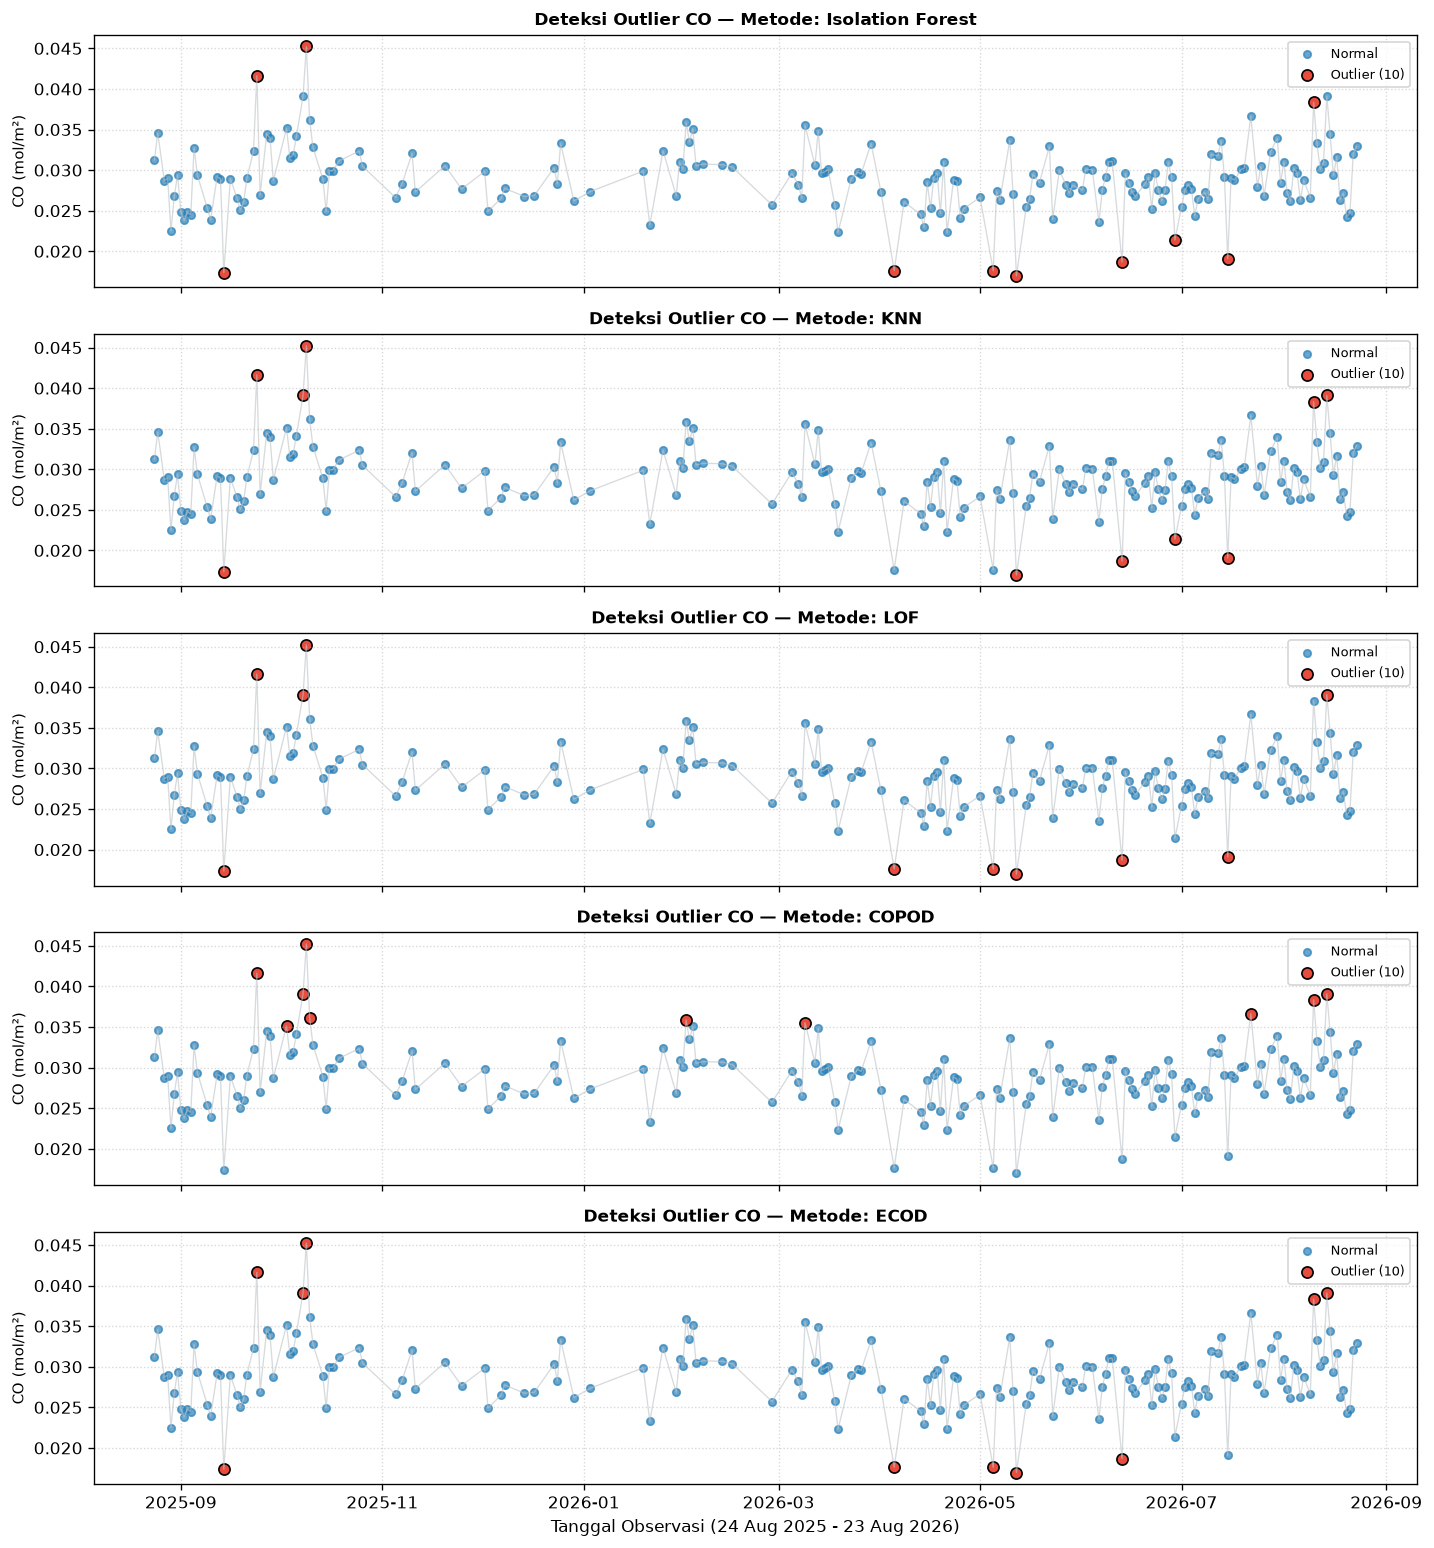

In [4]:
# Visualisasi Subplot 5 Metode Outlier Terpisah
fig, axes = plt.subplots(5, 1, figsize=(12, 13), sharex=True, dpi=120)

for i, (name, model) in enumerate(models.items()):
    ax = axes[i]
    normal_m = df_valid[df_valid[f'outlier_{name}'] == 0]
    outliers_m = df_valid[df_valid[f'outlier_{name}'] == 1]
    
    ax.plot(df_valid['date'], df_valid['CO'], color='#bdc3c7', linewidth=0.8, alpha=0.6)
    ax.scatter(normal_m['date'], normal_m['CO'], color='#2980b9', s=20, alpha=0.7, label='Normal')
    ax.scatter(outliers_m['date'], outliers_m['CO'], color='#e74c3c', s=45, edgecolors='black', label=f'Outlier ({len(outliers_m)})')
    ax.set_title(f'Deteksi Outlier CO — Metode: {name}', fontsize=10, fontweight='bold')
    ax.set_ylabel('CO (mol/m²)', fontsize=9)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.5)

plt.xlabel('Tanggal Observasi (24 Aug 2025 - 23 Aug 2026)', fontsize=10)
plt.tight_layout()
plt.show()

In [5]:
# 3. Pengosongan Nilai Outlier menjadi NaN
df_prep = df_raw.copy()
df_prep.loc[is_outlier, 'CO'] = np.nan
nan_setelah_outlier = df_prep['CO'].isna().sum()

# 4. Imputasi Linear Time Interpolation Sekaligus
df_clean = df_prep.copy()
df_clean['CO_clean'] = df_clean['CO'].interpolate(method='linear', limit_direction='both')
nan_akhir = df_clean['CO_clean'].isna().sum()

print(f"Jumlah NaN Setelah Outlier Dikosongkan : {nan_setelah_outlier} hari ({nan_setelah_outlier/total_rows*100:.2f}%)")
print(f"Jumlah NaN Setelah Imputasi Akhir      : {nan_akhir} hari (100% Terisi & Clean)")

# Simpan dataset bersih ke file CSV
df_save = df_clean[['date', 'CO_clean']].rename(columns={'CO_clean': 'CO'})
df_save.to_csv('../data/csv/clean/CO_clean.csv', index=False)
print("Dataset bersih disimpan ke '../data/csv/clean/CO_clean.csv'")

Jumlah NaN Setelah Outlier Dikosongkan : 184 hari (50.41%)
Jumlah NaN Setelah Imputasi Akhir      : 0 hari (100% Terisi & Clean)
Dataset bersih disimpan ke '../data/csv/clean/CO_clean.csv'


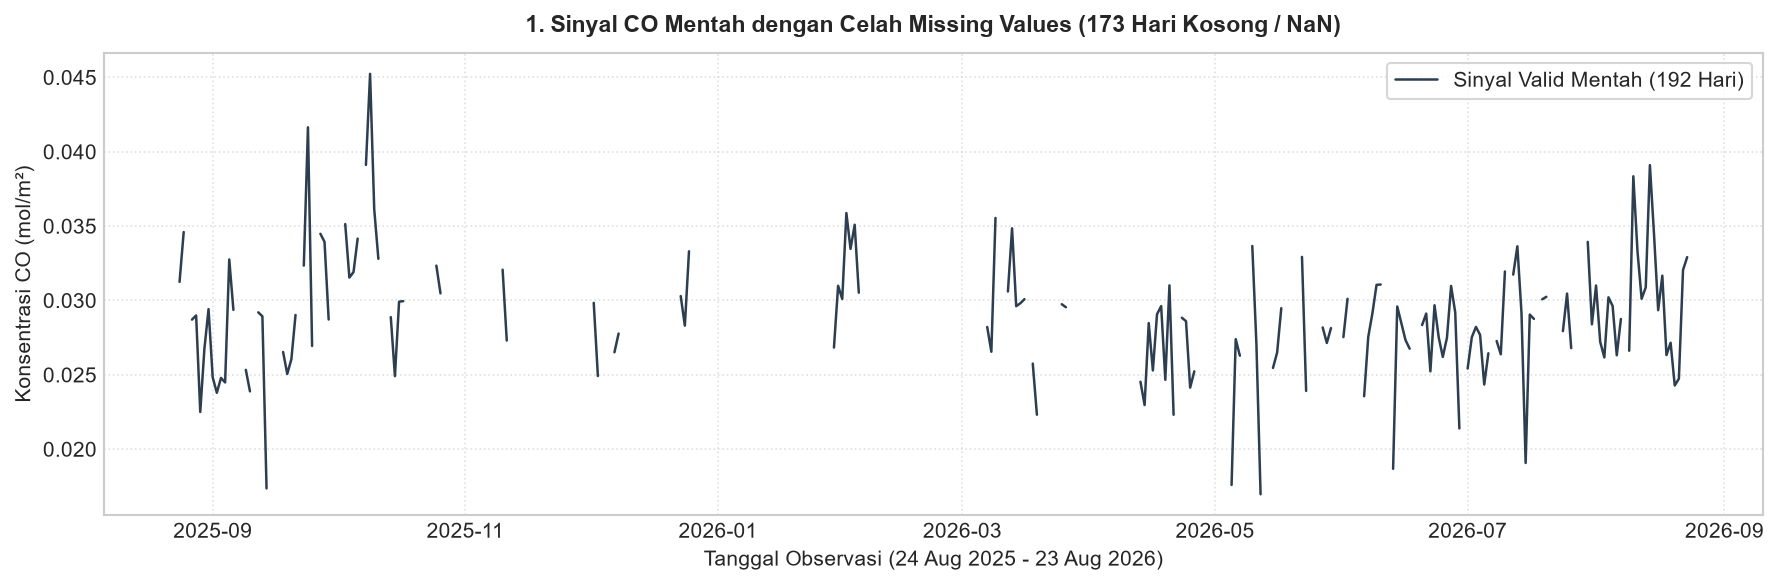

In [6]:
# Set Visual Style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Grafik 1: Missing Values (Data Mentah dengan Celah Kosong / NaN)
fig, ax = plt.subplots(figsize=(12, 4), dpi=150)
ax.plot(df_raw['date'], df_raw['CO'], color='#2c3e50', linewidth=1.2, label='Sinyal Valid Mentah (192 Hari)')
ax.set_title('1. Sinyal CO Mentah dengan Celah Missing Values (173 Hari Kosong / NaN)', fontsize=11, fontweight='bold', pad=10)
ax.set_xlabel('Tanggal Observasi (24 Aug 2025 - 23 Aug 2026)', fontsize=10)
ax.set_ylabel('Konsentrasi CO (mol/m²)', fontsize=10)
ax.legend(loc='upper right', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

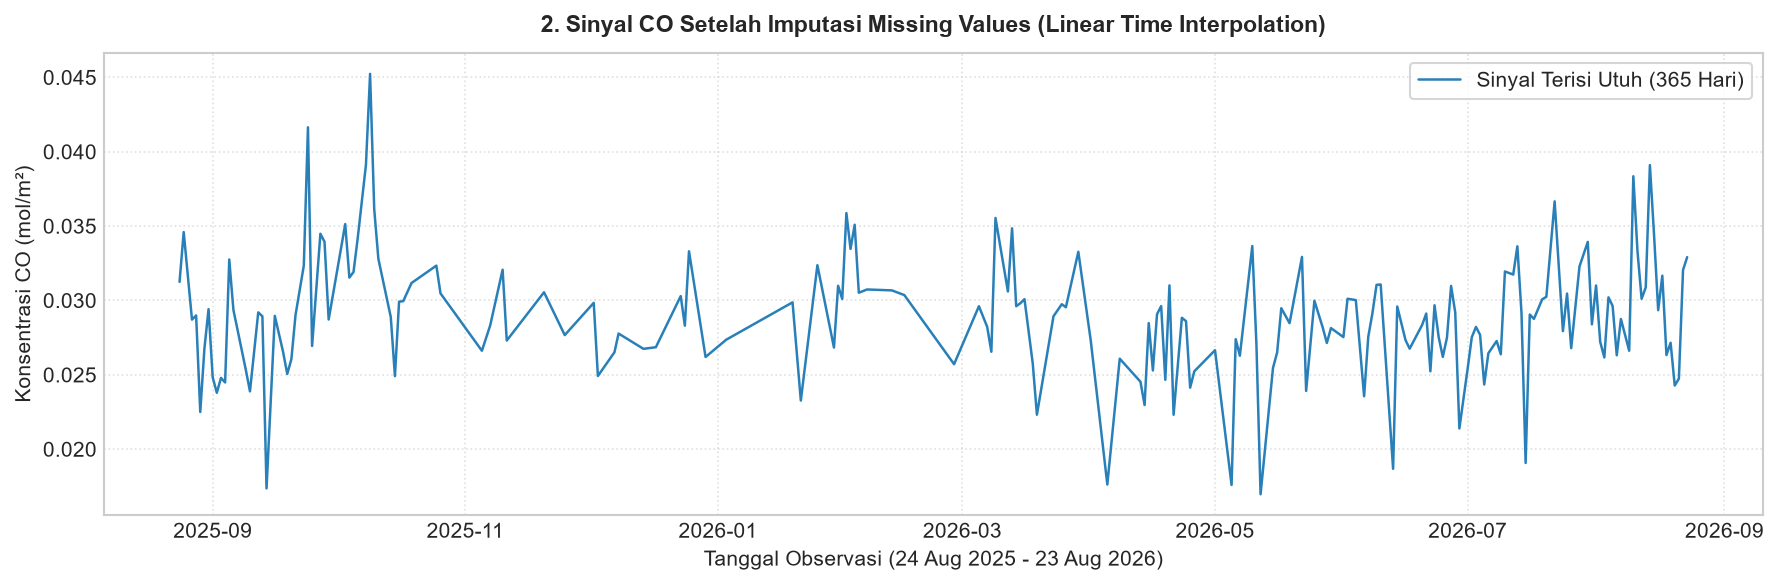

In [7]:
# Grafik 2: Sinyal Setelah Missing Values Diimputasi (Sebelum Cleaning Outlier)
df_raw_imputed = df_raw.copy()
df_raw_imputed['CO_imputed'] = df_raw_imputed['CO'].interpolate(method='linear', limit_direction='both')

fig, ax = plt.subplots(figsize=(12, 4), dpi=150)
ax.plot(df_raw_imputed['date'], df_raw_imputed['CO_imputed'], color='#2980b9', linewidth=1.2, label='Sinyal Terisi Utuh (365 Hari)')
ax.set_title('2. Sinyal CO Setelah Imputasi Missing Values (Linear Time Interpolation)', fontsize=11, fontweight='bold', pad=10)
ax.set_xlabel('Tanggal Observasi (24 Aug 2025 - 23 Aug 2026)', fontsize=10)
ax.set_ylabel('Konsentrasi CO (mol/m²)', fontsize=10)
ax.legend(loc='upper right', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

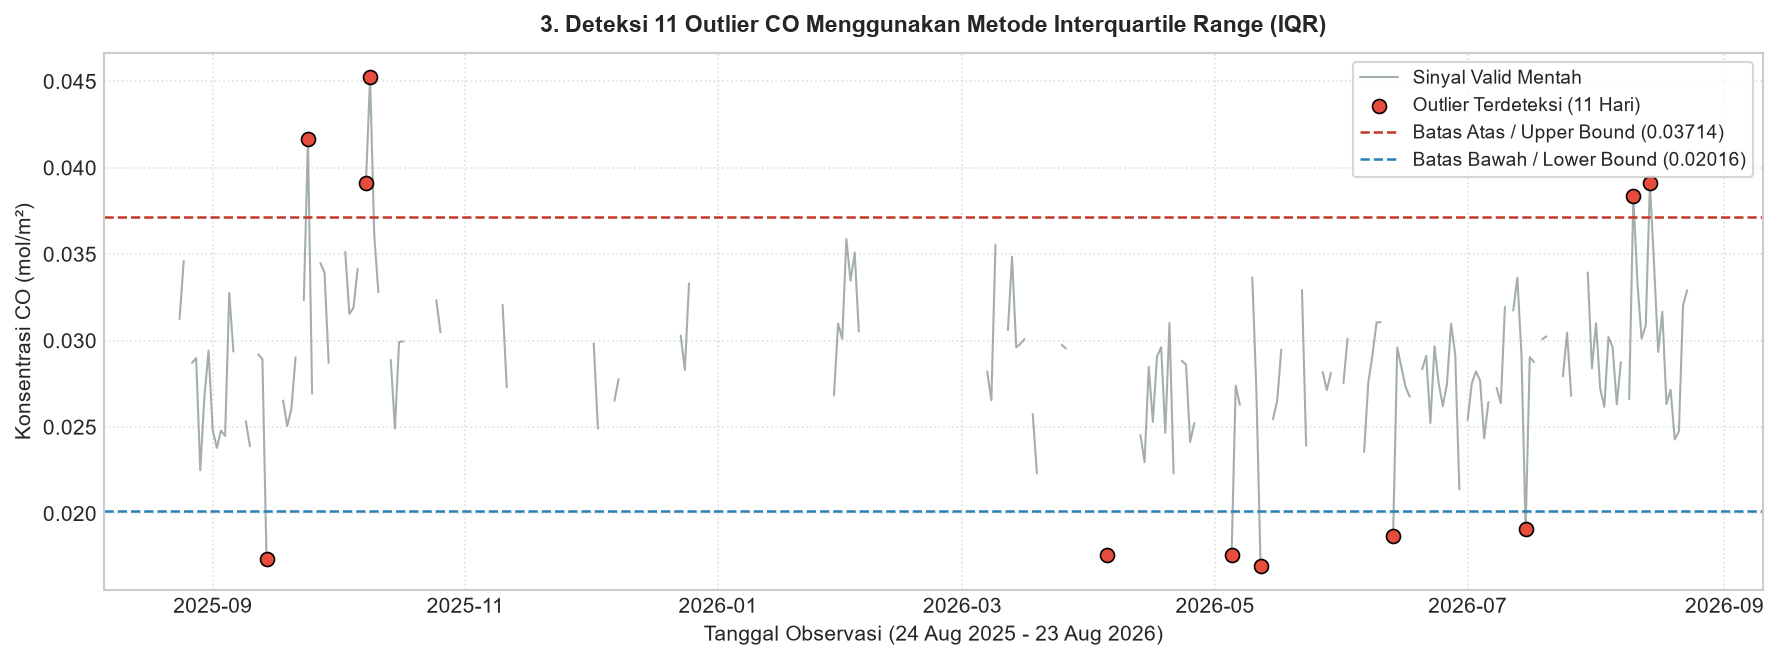

In [8]:
# Grafik 3: Deteksi Outlier Menggunakan Metode IQR
outliers_plot = df_raw[is_outlier]

fig, ax = plt.subplots(figsize=(12, 4.5), dpi=150)
ax.plot(df_raw['date'], df_raw['CO'], color='#7f8c8d', linewidth=1.0, alpha=0.7, label='Sinyal Valid Mentah')
ax.scatter(outliers_plot['date'], outliers_plot['CO'], color='#e74c3c', s=45, zorder=5, marker='o', edgecolor='black', linewidth=0.8, label=f'Outlier Terdeteksi ({len(outliers_plot)} Hari)')
ax.axhline(upper_bound, color='#c0392b', linestyle='--', linewidth=1.2, label=f'Batas Atas / Upper Bound ({upper_bound:.5f})')
ax.axhline(lower_bound, color='#2980b9', linestyle='--', linewidth=1.2, label=f'Batas Bawah / Lower Bound ({lower_bound:.5f})')
ax.set_title(f'3. Deteksi 11 Outlier CO Menggunakan Metode Interquartile Range (IQR)', fontsize=11, fontweight='bold', pad=10)
ax.set_xlabel('Tanggal Observasi (24 Aug 2025 - 23 Aug 2026)', fontsize=10)
ax.set_ylabel('Konsentrasi CO (mol/m²)', fontsize=10)
ax.legend(loc='upper right', frameon=True, fontsize=9)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

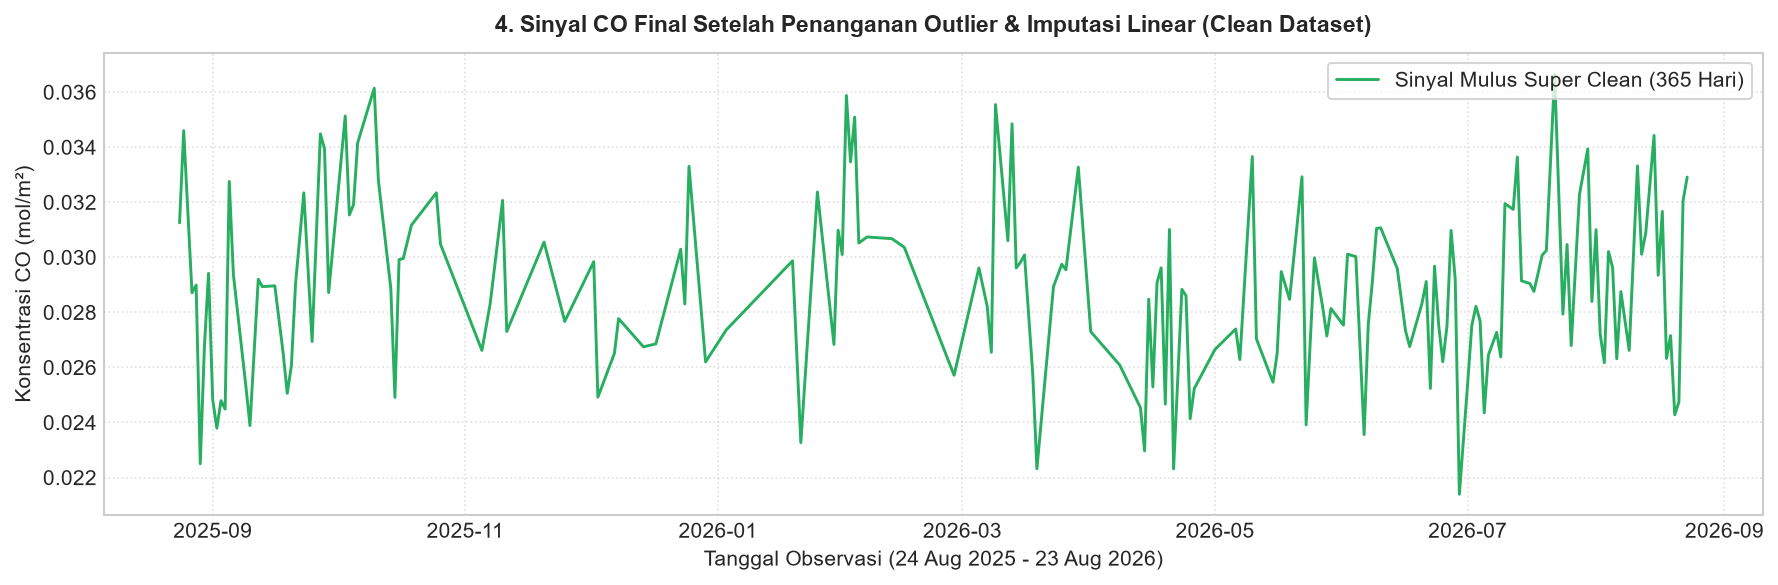

In [9]:
# Grafik 4: Sinyal CO Final Setelah Outlier Dibersihkan & Diimputasi
fig, ax = plt.subplots(figsize=(12, 4), dpi=150)
ax.plot(df_clean['date'], df_clean['CO_clean'], color='#27ae60', linewidth=1.4, label='Sinyal Mulus Super Clean (365 Hari)')
ax.set_title('4. Sinyal CO Final Setelah Penanganan Outlier & Imputasi Linear (Clean Dataset)', fontsize=11, fontweight='bold', pad=10)
ax.set_xlabel('Tanggal Observasi (24 Aug 2025 - 23 Aug 2026)', fontsize=10)
ax.set_ylabel('Konsentrasi CO (mol/m²)', fontsize=10)
ax.legend(loc='upper right', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()